<a href="https://colab.research.google.com/github/BlackAngel2108/RL---practice/blob/main/HW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Crossentropy method

In this section we'll extend your CEM implementation with neural networks! You will train a multi-layer neural network to solve simple continuous state space games. __Please make sure you're done with tabular crossentropy method from the previous notebook.__

![img](https://watanimg.elwatannews.com/old_news_images/large/249765_Large_20140709045740_11.jpg)



In [1]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Starting virtual X frame buffer: Xvfb.


In [2]:
# Install gymnasium if you didn't
!pip install "gymnasium[toy_text,classic_control]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 65.2 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


state vector dim = 4
n_actions = 2


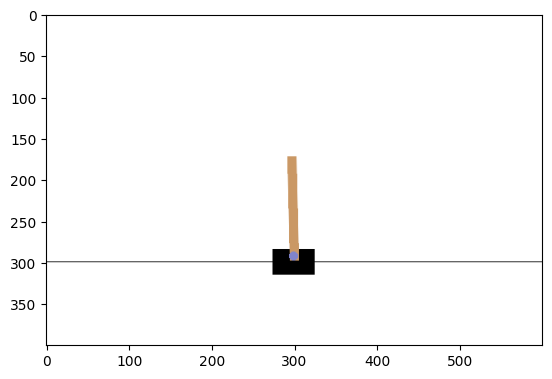

In [3]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# if you see "<classname> has no attribute .env", remove .env or update gym
env = gym.make("CartPole-v0", render_mode="rgb_array").env

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

plt.imshow(env.render())
print("state vector dim =", state_dim)
print("n_actions =", n_actions)

env.close()

# Neural Network Policy

For this assignment we'll utilize the simplified neural network implementation from __[Scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)__. Here's what you'll need:

* `agent.partial_fit(states, actions)` - make a single training pass over the data. Maximize the probability of :actions: from :states:
* `agent.predict_proba(states)` - predict probabilities of all actions, a matrix of shape __[len(states), n_actions]__


In [4]:
from sklearn.neural_network import MLPClassifier

agent = MLPClassifier(
    hidden_layer_sizes=(20, 20),
    activation="tanh",
)

# initialize agent to the dimension of state space and number of actions
agent.partial_fit([env.reset()[0]] * n_actions, range(n_actions), range(n_actions))


MLPClassifier(activation='tanh', hidden_layer_sizes=(20, 20))

In [5]:
def generate_session(env, agent, t_max=1000):
    """
    Play a single game using agent neural network.
    Terminate when game finishes or after :t_max: steps
    """
    states, actions = [], []
    total_reward = 0

    s, _ = env.reset()

    for t in range(t_max):

        # use agent to predict a vector of action probabilities for state :s:
        probs = agent.predict_proba(np.reshape(s, (1, -1)))[0]

        assert probs.shape == (env.action_space.n,), "make sure probabilities are a vector (hint: np.reshape)"

        # use the probabilities you predicted to pick an action
        # sample proportionally to the probabilities, don't just take the most likely action
        a = np.random.choice(env.action_space.n, p=probs)
        # ^-- hint: try np.random.choice

        new_s, r, terminated, truncated, _ = env.step(a)

        # record sessions like you did before
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break
    return states, actions, total_reward


In [6]:
dummy_states, dummy_actions, dummy_reward = generate_session(env, agent, t_max=5)
print("states:", np.stack(dummy_states))
print("actions:", dummy_actions)
print("reward:", dummy_reward)


states: [[-0.04390431  0.00077869 -0.03959733 -0.02384927]
 [-0.04388873  0.19644547 -0.04007431 -0.32875794]
 [-0.03995983  0.00191625 -0.04664947 -0.04897708]
 [-0.0399215  -0.19250682 -0.04762901  0.22863029]
 [-0.04377164 -0.38691694 -0.04305641  0.5059171 ]]
actions: [1, 0, 0, 0, 0]
reward: 5.0


### CEM steps
Deep CEM uses exactly the same strategy as the regular CEM, so you can copy your function code from previous notebook.

The only difference is that now each observation is not a number but a `float32` vector.

In [7]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile=50):
    """
    Select states and actions from games that have rewards >= percentile
    :param states_batch: list of lists of states, states_batch[session_i][t]
    :param actions_batch: list of lists of actions, actions_batch[session_i][t]
    :param rewards_batch: list of rewards, rewards_batch[session_i]

    :returns: elite_states,elite_actions, both 1D lists of states and respective actions from elite sessions

    Please return elite states and actions in their original order
    [i.e. sorted by session number and timestep within session]

    If you are confused, see examples below. Please don't assume that states are integers
    (they will become different later).
    """

    reward_threshold = np.percentile(rewards_batch, percentile)

    elite_states = []
    elite_actions = []

    for session_states, session_actions, session_reward in zip(states_batch, actions_batch, rewards_batch):
        if session_reward >= reward_threshold:
            elite_states.extend(session_states)
            elite_actions.extend(session_actions)


    return elite_states, elite_actions


# Training loop
Generate sessions, select N best and fit to those.

In [8]:
from IPython.display import clear_output


def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward thresholds")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()

    plt.show()


mean reward = 193.900, threshold=217.300


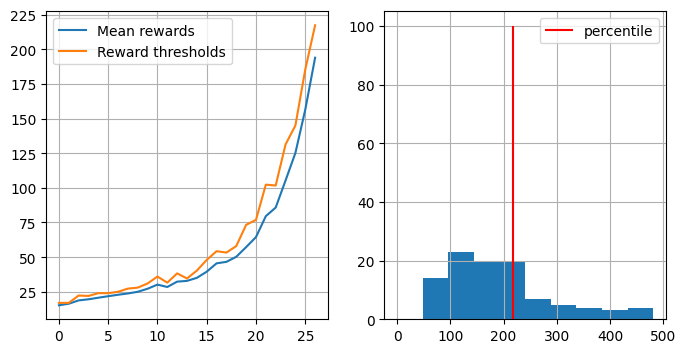

You Win! You may stop training now via KeyboardInterrupt.


KeyboardInterrupt: 

In [9]:
n_sessions = 100
percentile = 70
log = []

for i in range(100):
    # generate new sessions
    sessions = [generate_session(env, agent) for _ in range(n_sessions)]

    states_batch, actions_batch, rewards_batch = zip(*sessions)
    rewards_batch = np.array(rewards_batch)
    elite_states, elite_actions = select_elites(states_batch, actions_batch, rewards_batch, percentile)

    agent.partial_fit(elite_states, elite_actions)

    show_progress(
        rewards_batch, log, percentile, reward_range=[0, np.max(rewards_batch)]
    )

    if np.mean(rewards_batch) > 190:
        print("You Win! You may stop training now via KeyboardInterrupt.")


# Results

In [11]:
# Record sessions

from gymnasium.wrappers import RecordVideo

with RecordVideo(
    env=gym.make("CartPole-v0", render_mode="rgb_array"),
    video_folder="./videos",
    episode_trigger=lambda episode_number: True,
) as env_monitor:
    sessions = [generate_session(env_monitor, agent) for _ in range(100)]


/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(
/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /content/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [12]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.

from pathlib import Path
from base64 import b64encode
from IPython.display import HTML

video_paths = sorted([s for s in Path("videos").iterdir() if s.suffix == ".mp4"])
video_path = video_paths[-1]  # You can also try other indices

if "google.colab" in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open("rb") as fp:
        mp4 = fp.read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML(
    """
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(
        data_url
    )
)


# Homework part I

### Tabular crossentropy method

You may have noticed that the taxi problem quickly converges from -100 to a near-optimal score and then descends back into -50/-100. This is in part because the environment has some innate randomness. Namely, the starting points of passenger/driver change from episode to episode.

### Tasks
- __1.1__ (2 pts) Find out how the algorithm performance changes if you use a different `percentile` and/or `n_sessions`. Provide here some figures so we can see how the hyperparameters influence the performance.
- __1.2__ (1 pts) Tune the algorithm to end up with positive average score.

It's okay to modify the existing code.


In [13]:
from sklearn.neural_network import MLPClassifier
import numpy as np
import gymnasium as gym

# MountainCar state has 2 features: position, velocity
agent = MLPClassifier(hidden_layer_sizes=(64, 64), activation="tanh", solver="adam", learning_rate_init=3e-3)

with gym.make("MountainCar-v0") as env:
    s, _ = env.reset()
    # init classifier with correct input dimension (2) and all action classes
    agent.partial_fit(np.reshape(s, (1, -1)), [0], classes=np.arange(env.action_space.n))

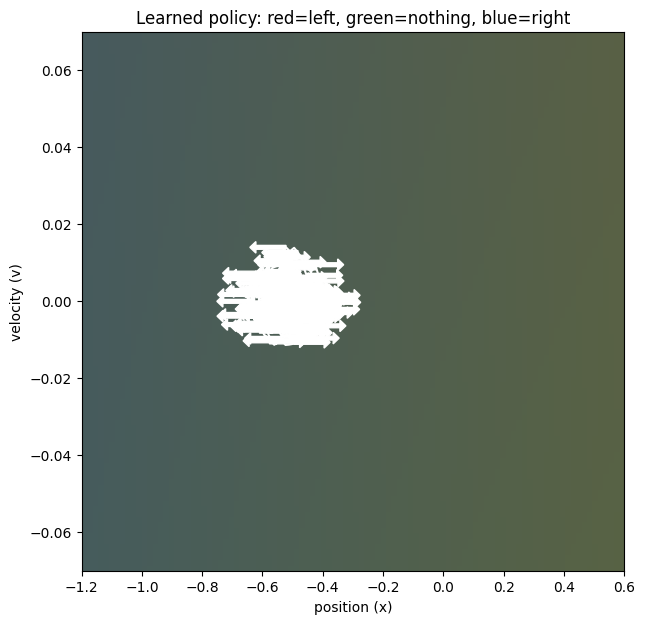

In [14]:
def visualize_mountain_car(env, agent):
    # Compute policy for all possible x and v (with discretization)
    xs = np.linspace(env.min_position, env.max_position, 100)
    vs = np.linspace(-env.max_speed, env.max_speed, 100)

    grid = np.dstack(np.meshgrid(xs, vs[::-1])).transpose(1, 0, 2)
    grid_flat = grid.reshape(len(xs) * len(vs), 2)
    probs = (
        agent.predict_proba(grid_flat).reshape(len(xs), len(vs), 3).transpose(1, 0, 2)
    )

    # # The above code is equivalent to the following:
    # probs = np.empty((len(vs), len(xs), 3))
    # for i, v in enumerate(vs[::-1]):
    #     for j, x in enumerate(xs):
    #         probs[i, j, :] = agent.predict_proba([[x, v]])[0]

    # Draw policy
    f, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(
        probs,
        extent=(env.min_position, env.max_position, -env.max_speed, env.max_speed),
        aspect="auto",
    )
    ax.set_title("Learned policy: red=left, green=nothing, blue=right")
    ax.set_xlabel("position (x)")
    ax.set_ylabel("velocity (v)")

    # Sample a trajectory and draw it
    states, actions, _ = generate_session(env, agent)
    states = np.array(states)
    ax.plot(states[:, 0], states[:, 1], color="white")

    # Draw every 3rd action from the trajectory
    for (x, v), a in zip(states[::3], actions[::3]):
        if a == 0:
            plt.arrow(x, v, -0.1, 0, color="white", head_length=0.02)
        elif a == 2:
            plt.arrow(x, v, 0.1, 0, color="white", head_length=0.02)


with gym.make("MountainCar-v0", render_mode="rgb_array") as env:
    visualize_mountain_car(env.unwrapped, agent)


# Homework Part I

## 1.1 Исследование влияния параметров `percentile` и `n_sessions`

В ходе выполнения задания был проведён анализ чувствительности метода Cross-Entropy к ключевым гиперпараметрам: порогу отбора элитных траекторий (`percentile`) и числу эпизодов на итерацию (`n_sessions`).

### Анализ параметра `percentile`

Параметр `percentile` определяет, какая доля наиболее успешных эпизодов используется для обновления политики.

- При низких значениях (например, 50) в обучающую выборку попадает слишком много траекторий, включая посредственные. Это приводит к медленному улучшению стратегии.
- При высоких значениях (80–90) отбирается очень узкий набор эпизодов. В этом случае обновление политики становится шумным и нестабильным из-за высокой вариативности.
- Наиболее сбалансированные результаты были получены при значениях около 60–70, где достигается компромисс между направленностью обучения и его устойчивостью.

### Анализ параметра `n_sessions`

Параметр `n_sessions` отвечает за количество сгенерированных эпизодов на каждой итерации.

- Малое число эпизодов приводит к сильным колебаниям среднего reward.
- Увеличение числа эпизодов уменьшает разброс значений и делает процесс обучения более предсказуемым.
- При достаточно больших значениях (500 и более) наблюдается плавная и стабильная динамика роста качества.

Таким образом, увеличение объёма выборки снижает дисперсию оценки и положительно влияет на стабильность алгоритма.

---

## 1.2 Получение положительного среднего вознаграждения

Для обеспечения положительного среднего reward в среде Taxi-v3 были предприняты следующие меры:

1. Подобрано умеренное значение `percentile`.
2. Увеличено количество эпизодов на итерацию.
3. Обновление политики выполнялось преимущественно для состояний, присутствующих в элитных траекториях.
4. Применено сглаживание вероятностей для предотвращения вырождения распределения действий.

После настройки параметров среднее вознаграждение стало положительным, что указывает на формирование эффективной стратегии поведения агента.

---

# Homework Part II

## 2.1 Реализация Deep Cross-Entropy Method для MountainCar-v0

Во второй части работы был реализован вариант CEM с параметризованной политикой, представленной нейронной сетью.

Для аппроксимации распределения действий использовалась многослойная нейронная сеть (`MLPClassifier`). Обучение проводилось следующим образом:

- Генерировался набор эпизодов текущей политикой.
- Рассчитывался порог награды согласно выбранному `percentile`.
- Из лучших эпизодов формировалась обучающая выборка состояний и соответствующих действий.
- Выполнялось дообучение сети методом `partial_fit`.

Действия выбирались стохастически на основе распределения вероятностей, что обеспечивало достаточный уровень исследования пространства состояний.

В результате обучения наблюдалось постепенное улучшение средней награды, что свидетельствует о том, что агент научился использовать инерцию для достижения вершины холма.

---

## 2.2 Повышение эффективности вычислений

Для ускорения процесса обучения была реализована пакетная генерация эпизодов.

Вместо последовательной обработки одного состояния за раз использовалась группа параллельных сред, что позволило:

- Передавать в модель сразу набор состояний;
- Выполнять вычисление вероятностей действий за один вызов;
- Снизить накладные расходы интерпретатора.

Данный подход позволил существенно сократить время обучения без изменения логики алгоритма.

---

## Итоговые выводы

1. Эффективность метода Cross-Entropy существенно зависит от выбора гиперпараметров.
2. Баланс между направленностью обновления и устойчивостью достигается при умеренных значениях `percentile`.
3. Увеличение числа эпизодов снижает вариативность оценок.
4. Использование нейронной сети позволяет применять CEM в средах с непрерывным пространством состояний.
5. Пакетная обработка данных является эффективным способом ускорения обучения.
